<a href="https://colab.research.google.com/github/mjmj002/Sparta/blob/main/Python/day8_project_2%EC%A3%BC%EC%B0%A8_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **2주차 프로젝트**

이번 프로젝트에서는 Upbit API를 활용해 암호화폐의 시세 데이터를 수집하고,
이를 전처리 → 데이터베이스 저장 → 시각화까지 연결하는 데이터 파이프라인 전체 흐름을 구현합니다.

과제는 **필수 과제**와 **도전 과제**로 나뉘며, 필수 과제는 반드시 제출해야 하고, 도전 과제는 선택적으로 수행하면 됩니다.

---

**[필수 과제]**
*   문제1. 종가와 시가의 차이 계산

*   문제2. 5일 이동평균선 계산 및 결측치 처리

**[도전 과제]**
*   문제3. 종가와 5일 이동평균선 시각화

In [ ]:
# 필요한 라이브러리 설치 (주석 해제 후 실행)
!pip install pyupbit pyjwt pandas matplotlib

In [ ]:
import pyupbit
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import time
import warnings

# 경고 메시지 숨기기
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# Upbit API 클래스 구현

In [ ]:
import requests
def get_current_prices_api(tickers):
  """
  업비트 API 사용하여 여러 암호화폐의 현재가 조회하는 함수

  Args:
    tickers (list) : 조회할 암호화폐 ticker 리스트

  Returns:
    dict: {ticker: 현재가} 형태의 딕셔너리

  """
  url = "https://api.upbit.com/v1/ticker"
  headers = {"accept" : "application/json"} # 정보. 데이터 형식 : json

  # 여러 티커를 쉼표로 연결
  # 가지고 있는 데이터 = 파이썬 리스트 형태 -> 업비트 서버는 리스트 채로 이해못함 -> 쉼표 넣어서 하나의 긴 문장으로
  markets_param = ",".join(tickers) # 리스트를 문자열로 합치기 -> "KRW-BTC,KRW-ETH,KRW-XRP"
  params = {"markets" : markets_param} # params: 업비트가 요구하는 양식(markets라는 키값)에 맞춰 데이터를 포장

  # markets 업비트 규칙
  # {"markets" : "KRW-BTC,KRW-ETH,KRW-XRP"}

  # API 요청
  response = requests.get(url, headers=headers, params=params) # (url, 데이터형식, markets 코인 목록)
  prices_data = response.json() # 파이썬이 읽을 수 있는 리스트와 딕셔너리로 변환

  """
  # prices_data의 실제 모습 (리스트 안에 딕셔너리가 줄줄이 사탕처럼 있음)
  [
      {'market': 'KRW-BTC', 'trade_price': 100000000, 'high_price': 101000000, 'low_price': 99000000 ...},
      {'market': 'KRW-ETH', 'trade_price': 5000000, 'high_price': 5100000, 'low_price': 4900000 ...}
  ]
  """
  # 딕셔너리 형태로 변환
  prices = {}
  for data in prices_data:
    prices[data['market']] = data['trade_price'] # 'market'이라는 이름표를 '키(Key)'로, 'trade_price'라는 가격을 '값(Value)'으로 prices에 담기

  return prices
  """
  # for문을 통과한 후의 prices 모습 (정리된 모습)
  {
      'KRW-BTC': 100000000,
      'KRW-ETH': 5000000
  }
  """

# 똑같은 결과(비트코인 가격)를 얻기 위해 서로 다른 두 가지 방법
print(get_current_prices_api(["KRW-BTC"]))  # 내가 직접 만든 함수로 가격 가져오기
pyupbit.get_current_price(["KRW-BTC"])      # 남이 미리 잘 만들어둔 라이브러리 함수로 가격 가져오기. pyupbit라는 라이브러리를 만든 전문가들이 미리 짜놓은 기능을 빌려 씀

{'KRW-BTC': 103434000.0}


103434000.0

In [ ]:
class UpbitDataCollector: # 붕어빵 틀(설계도)
  """ Upbit API를 활용한 데이터 수집 클래스 """

# 초기 세팅
  def __init__(self): # 'Initialize(초기화)' 만들어지는 순간 한번 실행되는 초기 설정값들. 나 자신
      # 준비만 해두고 아직 안 넣은 초기 상태
      self.supported_tickers = None # 이 함수가 지원하는 코인 목록(메모리) 을 일단 비워둔 채로 준비. 저장 공간(변수). 나중에 데이터 받아옴

  def get_krw_tickers(self):
      """KRW 마켓의 모든 ticker 조회"""
      try:
        tickers = pyupbit.get_tickers(fiat="KRW") # pyupbit:전문가가 만든 도구 빌려옴. 원화로 살 수 있는 코인 목록 가져오기
        self.supported_tickers = tickers # UpbitDataCollector에서 supported_tickers라는 전용 사물함에 데이터를 딱 저장
        return tickers
      except Exception as e: # 끊기거나 에러로 종료되지 않게 안전장치 개념
        print(f"티커 조회 오류: {e}") # 에러시에 빈 주머니 [] 출력

  def get_current_prices(self, tickers):
    """현재가 조회"""
    try:
        if isinstance(tickers, str):
            return pyupbit.get_current_price(tickers)
        else:
            return pyupbit.get_current_price(tickers)
    except Exception as e:
        prinf(f"현재가 조회 오류: {e}")
        return None

  # 업비트에서 시세 데이터를 가져와 분석하기 좋은 형태로 가공
  def get_ohlcv_data(self, ticker, interval="day", count=30):
      """OHLCV 데이터 조회"""
      try:
          df = pyupbit.get_ohlcv(ticker, interval=interval, count=count)
          if df is not None: # 데이터가 비어있지 않다면, 새로운 열(ticker)을 만들고 해당 코인의 이름(예: KRW-BTC)을 채워 넣음
                             # 나중에 여러 코인의 데이터를 하나로 합쳤을 때, 어떤 행이 어떤 코인의 데이터인지 구분하기 위해서
              df['ticker'] = ticker # df['ticker'] 추가	우측에 ticker 컬럼이 생겨서 "이건 비트코인이다"라고 명시
              df.reset_index(inplace=True) # 인덱스로 잡혀있던 날짜를 일반적인 컬럼(열)으로 이동
          return df                        # Pandas에서 데이터를 그룹화(groupby)하거나 시각화할 때, 날짜가 인덱스에 있는 것보다 일반 컬럼에 있는 것이 조작하기 훨씬 편하기 때문
      except Exception as e:
          print(f"{ticker} OHLCV 데이터 조회 오류: {e}")
          return None
          # -----------| ---------|----------
          # ticker         df.data   df.data

  def get_multiple_ohlcv(self, tickers, interval="day", count=30, delay=0.1):
      """여러 티커의 OHLCV 데이터 일괄 조회"""
      all_data = [] # 비어 있는 리스트(장바구니)를 준비

      for ticker in tickers: # 분석하고 싶은 코인 리스트(예: BTC, ETH, XRP)를 하나씩 꺼냄
          print(f"{ticker} 데이터 수집 중 ...")
          data = self.get_ohlcv_data(ticker, interval, count) # 위에서 만든 get_ohlcv_data를 호출해서 개별 코인의 데이터프레임을 가져옴
          if data is not None:
              all_data.append(data) # 수집된 개별 데이터프레임을 리스트에 쌓음
          time.sleep(delay) # API 호출 제한 고려. 업비트 API 서버에 너무 빠르게 요청을 보내면 "공격"으로 간주되어 차단당할 수 있는데, 이를 방지

      # 마지막에 리스트에 담긴 모든 데이터프레임을 하나로 합쳐줌
      # 수집한 여러 개의 데이터 조각들을 하나의 거대한 데이터 판(Master Table)으로 합치는 마지막 단계
      if all_data:
          return pd.concat(all_data, ignore_index=True) # 데이터 이어붙이기/ 현재는 리스트 형태 쭉 나열된 -> 세로방향으로 이어짐
                                        # False일 때: 0, 1, 2, 0, 1, 2, 0, 1, 2... (인덱스 중복 발생)
                                        # True일 때: 0, 1, 2, 3, 4, 5, 6, 7, 8... (새로운 순차적 번호 부여)
      return pd.DataFrame() # # 만약 수집된 데이터가 하나도 없다면 빈 데이터프레임 반환

# 클래스 인스턴스 생성
collector = UpbitDataCollector() #collector (인스턴스): 설계도를 보고 실제로 만들어진 '붕어빵'
# 이제 이 collector라는 이름을 통해 우리가 만든 함수들(get_ohlcv_data, get_multiple_ohlcv 등)을 실제로 호출할 수 있음


# 1. str  "122220000"
# 2. dict {"KRW-BTC":"12002222"}

# 데이터 수집

In [ ]:
major_tickers = "KRW-BTC" #["KRW-BTC","KRW-ETC","KRW-XRP"]

# 현재가 조회
current_prices = collector.get_current_prices(major_tickers)
current_prices

103434000.0

In [ ]:
major_tickers = ["KRW-BTC","KRW-ETC","KRW-XRP"]

# 현재가 조회
current_prices = collector.get_current_prices(major_tickers)
current_prices

{'KRW-BTC': 103434000.0, 'KRW-ETC': 12260.0, 'KRW-XRP': 2099.0}

In [ ]:
def collect_market_data():
    """시장 데이터 수집 함수"""

    # 주요 암호화폐 선택
    major_tickers = ["KRW-BTC","KRW-ETC","KRW-XRP"]
    print(f"\n분석 대상 티커: {major_tickers}")

    # 현재가 조회
    # current_prices는 {"KRW-BTC": 98000000, "KRW-ETH": 4500000}와 같은 딕셔너리(Dictionary) 형태
    current_prices = collector.get_current_prices(major_tickers)
    print(f"\n현재가 정보:")
    for ticker, price in current_prices.items(): # 딕셔너리의 Key(티커명)와 Value(현재가)를 쌍으로 묶어 하나씩 꺼내줌
        print(f"{ticker}: {price:,}원") # 3자리마다 콤마

    # OHLCV 데이터 수집 (최근 30일)
    print(f"\nOHLCV 데이터 수집 중...")
    ohlcv_data = collector.get_multiple_ohlcv(major_tickers, count=30)

    print(f"수집된 데이터 행 수: {len(ohlcv_data)}")
    print(f"데이터 컬럼: {list(ohlcv_data.columns)}")

    return ohlcv_data, current_prices

# 데이터 수집 실행
raw_data, prices = collect_market_data()


분석 대상 티커: ['KRW-BTC', 'KRW-ETC', 'KRW-XRP']

현재가 정보:
KRW-BTC: 103,434,000.0원
KRW-ETC: 12,260.0원
KRW-XRP: 2,099.0원

OHLCV 데이터 수집 중...
KRW-BTC 데이터 수집 중 ...
KRW-ETC 데이터 수집 중 ...
KRW-XRP 데이터 수집 중 ...
수집된 데이터 행 수: 90
데이터 컬럼: ['index', 'open', 'high', 'low', 'close', 'volume', 'value', 'ticker']


In [ ]:
# 수집된 데이터 미리보기
print(f"\n데이터 형태: {raw_data.shape}")
print(f"\n데이터 타입:\n{raw_data.dtypes}")


데이터 형태: (90, 8)

데이터 타입:
index     datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume           float64
value            float64
ticker            object
dtype: object


In [ ]:
raw_data.head(10)

,index,open,high,low,close,volume,value,ticker
0,2026-02-21 09:00:00,100066000.0,100932000.0,99415000.0,99986000.0,775.448525,7.766837e+10,KRW-BTC
1,2026-02-22 09:00:00,100033000.0,100263000.0,98912000.0,99542000.0,698.639869,6.965085e+10,KRW-BTC
2,2026-02-23 09:00:00,99579000.0,99580000.0,94346000.0,95352000.0,3494.871793,3.364230e+11,KRW-BTC
3,2026-02-24 09:00:00,95352000.0,95762000.0,92000000.0,93807000.0,3095.249243,2.892256e+11,KRW-BTC
4,2026-02-25 09:00:00,93807000.0,100482000.0,93400000.0,97937000.0,3478.094668,3.369904e+11,KRW-BTC
5,2026-02-26 09:00:00,97935000.0,99223000.0,96343000.0,97449000.0,1956.336104,1.915557e+11,KRW-BTC
6,2026-02-27 09:00:00,97450000.0,98600000.0,95061000.0,96121000.0,1703.633067,1.648827e+11,KRW-BTC
7,2026-02-28 09:00:00,96120000.0,98601000.0,92632000.0,97626000.0,2847.008072,2.699393e+11,KRW-BTC
8,2026-03-01 09:00:00,97626000.0,99005000.0,95100000.0,95904000.0,2045.735020,1.986650e+11,KRW-BTC
9,2026-03-02 09:00:00,95906000.0,102200000.0,95871000.0,100520000.0,3475.719795,3.444159e+11,KRW-BTC


In [ ]:
df = raw_data.head(5)
df
#print(df)

,index,open,high,low,close,volume,value,ticker
0,2026-02-21 09:00:00,100066000.0,100932000.0,99415000.0,99986000.0,775.448525,7.766837e+10,KRW-BTC
1,2026-02-22 09:00:00,100033000.0,100263000.0,98912000.0,99542000.0,698.639869,6.965085e+10,KRW-BTC
2,2026-02-23 09:00:00,99579000.0,99580000.0,94346000.0,95352000.0,3494.871793,3.364230e+11,KRW-BTC
3,2026-02-24 09:00:00,95352000.0,95762000.0,92000000.0,93807000.0,3095.249243,2.892256e+11,KRW-BTC
4,2026-02-25 09:00:00,93807000.0,100482000.0,93400000.0,97937000.0,3478.094668,3.369904e+11,KRW-BTC


In [ ]:
raw_data

,index,open,high,low,close,volume,value,ticker
0,2026-02-21 09:00:00,100066000.0,100932000.0,99415000.0,99986000.0,7.754485e+02,7.766837e+10,KRW-BTC
1,2026-02-22 09:00:00,100033000.0,100263000.0,98912000.0,99542000.0,6.986399e+02,6.965085e+10,KRW-BTC
2,2026-02-23 09:00:00,99579000.0,99580000.0,94346000.0,95352000.0,3.494872e+03,3.364230e+11,KRW-BTC
3,2026-02-24 09:00:00,95352000.0,95762000.0,92000000.0,93807000.0,3.095249e+03,2.892256e+11,KRW-BTC
4,2026-02-25 09:00:00,93807000.0,100482000.0,93400000.0,97937000.0,3.478095e+03,3.369904e+11,KRW-BTC
...,...,...,...,...,...,...,...,...
85,2026-03-18 09:00:00,2238.0,2272.0,2135.0,2177.0,1.498229e+08,3.291422e+11,KRW-XRP
86,2026-03-19 09:00:00,2177.0,2200.0,2121.0,2152.0,1.024159e+08,2.213314e+11,KRW-XRP
87,2026-03-20 09:00:00,2152.0,2183.0,2137.0,2160.0,6.913011e+07,1.493256e+11,KRW-XRP
88,2026-03-21 09:00:00,2159.0,2171.0,2110.0,2122.0,4.130105e+07,8.894853e+10,KRW-XRP


In [ ]:
# ===========================
#  ticker	KRW-BTC	KRW-BTC, KRW-ETC, KRW-XRP
# ===========================

key = raw_data.groupby('ticker')
print(key.groups.keys())
print(key.groups.values())

for key, each_df in raw_data.groupby('ticker'):
    print(key)
    display(each_df.head(2))

dict_keys(['KRW-BTC', 'KRW-ETC', 'KRW-XRP'])
dict_values([Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
      dtype='int64'), Index([30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47,
       48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
      dtype='int64'), Index([60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89],
      dtype='int64')])
KRW-BTC


,index,open,high,low,close,volume,value,ticker
0,2026-02-21 09:00:00,100066000.0,100932000.0,99415000.0,99986000.0,775.448525,7.766837e+10,KRW-BTC
1,2026-02-22 09:00:00,100033000.0,100263000.0,98912000.0,99542000.0,698.639869,6.965085e+10,KRW-BTC


KRW-ETC


,index,open,high,low,close,volume,value,ticker
30,2026-02-21 09:00:00,12870.0,14460.0,12800.0,13290.0,1.971376e+06,2.753034e+10,KRW-ETC
31,2026-02-22 09:00:00,13290.0,13290.0,12460.0,12520.0,4.873132e+05,6.287081e+09,KRW-ETC


KRW-XRP


,index,open,high,low,close,volume,value,ticker
60,2026-02-21 09:00:00,2101.0,2153.0,2090.0,2103.0,7.232020e+07,1.531607e+11,KRW-XRP
61,2026-02-22 09:00:00,2103.0,2111.0,2032.0,2051.0,7.741501e+07,1.602538e+11,KRW-XRP


# 데이터 전처리

## [필수 과제] 문제1: 종가와 시가의 차이 계산
종가와 시가의 차이를 계산하여 price_change 컬럼에 저장하시오


### 📌 구현 단계
1. **`price_change` 컬럼 생성**  
   - `close`(종가) - `open`(시가)의 차이를 계산하여 새로운 컬럼으로 추가한다.
2. **`price_change_pct` 컬럼 계산**
   - `price_change / open * 100`으로 변동률(%)을 계산한다.
3. **`high_low_diff` 컬럼 추가**
   - `high - low`를 계산하여 일중 변동폭을 나타내는 컬럼을 만든다.



<details>
<summary>💡 구현 힌트 (펼쳐보기)</summary>

- DataFrame의 컬럼 간 계산은 바로 가능합니다.
  ```python
  df['price_change'] = df['close'] - df['open']
  df['price_change_pct'] = (df['price_change'] / df['open']) * 100

- 추가 컬럼은 반드시 원본 데이터프레임에 병합합니다.
</details>  

<br>  

---
<br>  
  
## [필수 과제] 문제2: 5일 이동평균선 계산 및 결측치 처리
5일 이동평균선 값을 계산하여 'ma5' 컬럼에 저장하고 결측치를 처리하시오


### 📌 구현 단계
1. **이동평균선(`ma5`) 계산**  
   - 각 코인(`ticker`)별로 `close` 기준 5일 이동평균을 계산한다.
2. **`결측치 처리**
   - 이동평균 계산 초기에 생기는 NaN을 `close` 값으로 대체한다.
3. **전처리 완료 후 컬럼 순서 정리**
   - `ma5` 컬럼을 포함하여 최종 순서를 정돈한다.



<details>
<summary>💡 구현 힌트 (펼쳐보기)</summary>

- 이동평균은 **rolling() 메서드**를 활용할 수 있습니다.
- 티커별로 계산하려면 **조건 필터링(mask)** 또는 **groupby()** 로 나누어 수행합니다.
- 결측치 보정 시에는 **fillna()** 메서드를 활용해 보세요.
- 이동평균을 추가한 후에는 **데이터프레임 컬럼 순서**를 다시 맞춰줍니다.

In [ ]:
def preprocess_data(df):
    """데이터 전처리 함수"""
    print("=== 데이터 전처리 시작 ===")

    # 데이터 복사
    processed_df = df.copy() # 원본 설계도는 파일철에 두고, 복사기로 복사본을 한 장 뽑아서 그 위에 낙서(전처리)를 하겠다고 선언
    # 날짜 컬럼 처리
    if 'index' in processed_df.columns:
        processed_df['date'] = processed_df['index'] # 'index'라는 컬럼의 내용을 'date'라는 새로운 컬럼에 그대로 복사. 똑같은 날짜 정보가 두 군데에 있게 됨
        processed_df.drop('index', axis=1, inplace=True) # axis=1 가로(행)가 아니라 세로(열)를 지워라. inplace=True 지운 결과를 다른 곳에 저장하지 말고, 지금 이 데이터프레임에서 바로 삭제

    # 날짜를 문자열로 반환 (DB 저장용)
    # dt: 'Datetime'의 약자로, 날짜와 시간 데이터에 접근하겠다는 뜻
    # strftime: 'String Format Time'의 약자로, 날짜 데이터를 특정한 형식의 문자열(String)로 바꾸겠다는 명령어
    processed_df['date_str'] = processed_df['date'].dt.strftime('%Y-%m-%d %H:%M:%S')

    # 기술적 지표 계산
    #### 문제1) 종가와 시가의 차이 계산의 답안을 작성해주세요####
    # 종가 시가 가격 변화량 계산
    # price_change 컬럼 생성
    # close(종가) - open(시가)의 차이를 계산하여 새로운 컬럼으로 추가한다.

    processed_df['price_change'] = processed_df['close'] - processed_df['open']

    # 가격 변동률 계산하기
    # price_change_pct 컬럼 계산
    # price_change / open * 100으로 변동률(%)을 계산한다.
    processed_df['price_change_pct'] = (processed_df['price_change']) / processed_df['open'] * 100

    # 고가와 저가를 계산한 차이값 컬럼 만들기
    # high_low_diff 컬럼 추가
    # high - low를 계산하여 일중 변동폭을 나타내는 컬럼을 만든다.
    processed_df['high_low_diff'] = processed_df['high'] - processed_df['low']

    #### 문제2) 5일 이동평균선 계산 및 결측치 처리의 답안을 작성해주세요.
    # ticker per 5day move average line calculate
    # 티커별 5일 이동평균선 계산해보기~
    # KRW-BTC, KRW-ETC, KRW-XRP
    tickers = processed_df['ticker'].unique() # 데이터프레임 안에 들어있는 중복된 코인 이름들을 제거하고 딱 한 번씩만 뽑아냄
                                              # ['KRW-BTC', 'KRW-ETC', 'KRW-XRP'] 리스트가 만들어짐

    # 결측치 값 종가로 대체하기
    processed_df['ma5'] = 0.0

    # KRW-BTC, KRW-ETC, KRW-XRP 세개니까
    # 세번 반복
    for ticker in tickers:
        # 90개의 행중의 티커 이름을 가진애들과 30개가 있음
        # ticker  BTC 값이 같은 애들은 mask에 넣어 놓겠다.
        mask = processed_df['ticker'] == ticker  # "지금 내가 계산할 코인만 골라내기" 위한 필터(가면)
        # def add(a, b) a= 5, b= 1 rolling 몇개씩 묶어서 볼거냐 라는함수에
        # 5개씩 묶어서 보겠다.
        # mean 평균 값을 넣겠다
        # mask = ticker 별로 서른개씩 가져온 값의 종가를.
        # rolling을 통해 5개씩 묶을건데,
        # mean그 값의 평균을 mean 계산해서
        # processed_df[mask, ma5]에 넣겠다.
        processed_df.loc[mask, 'ma5'] = processed_df.loc[mask, 'close'].rolling(window=5, min_periods=1).mean()
        # 전체 데이터 중에서 mask(해당 코인)에 해당하는 줄의 ma5 칸에만 계산 결과를 집어넣어라"라는 뜻
        # loc를 쓰지 않고 그냥 대입하면 다른 코인의 데이터가 덮어씌워질 수 있기 때문에, 정확한 위치를 지정해주는 것

        # rolling(window=5): 현재 행을 기준으로 위로 5개를 묶음
        # min_periods=1: 원래 5일 이동평균은 데이터가 5개 모여야 계산이 되는데, 이 옵션을 주면 1개만 있어도(첫째 날부터) 평균을 내기 시작
        # 초반에 생기는 빈칸(NaN)을 최소화할 수 있음

        #.fillna(값)의 역할: "빈칸 메우기". 만약 데이터가 NaN(빈칸)이라면, 괄호 안의 값으로 대신 채워라
        # 종가로 ma5를 채워라
        # 이동평균선(MA5) 계산 후 발생할 수 있는 데이터의 빈칸(결측치)을 메워주는 '최종 마감 처리' 단계
        # 종가로 채우는 이유: 5일치 데이터가 없어서 평균을 못 낸다면, 그날의 실제 가격(종가)을 일단 평균값 대용으로 사용하는 것이 데이터 분석에서 흔히 쓰는 합리적인 방법
        processed_df['ma5'] = processed_df['ma5'].fillna(processed_df['close'])

        # 컬럼 순서 정리
        columns_order = ['date', 'date_str', 'ticker', 'open', 'high', 'low', 'close', 'volume',
                        'price_change', 'price_change_pct', 'high_low_diff', 'ma5']

        processed_df = processed_df[columns_order]
        # 1 순서 변경: 리스트에 적힌 순서대로 열의 위치를 바꿈
        # 2 필터링: 만약 columns_order 리스트에 적지 않은 임시 컬럼(예: 계산용으로 썼던 중간 단계 데이터)이 있다면, 이 과정에서 자동으로 삭제. 필요한 것만 딱 골라내는 효과

    return processed_df # 함수 내부에서 만든 복사본(processed_df)을 함수 밖으로 던져줌

# 그러면 processed_data라는 변수가 그 결과물을 받아서 저장함. 이제 이 변수를 가지고 그래프를 그리거나 DB에 저장할 수 있음
# 데이터 전처리 실행
processed_data = preprocess_data(raw_data)

=== 데이터 전처리 시작 ===


In [ ]:
processed_data.head(10)

,date,date_str,ticker,open,high,low,close,volume,price_change,price_change_pct,high_low_diff,ma5
0,2026-02-21 09:00:00,2026-02-21 09:00:00,KRW-BTC,100066000.0,100932000.0,99415000.0,99986000.0,775.448525,-80000.0,-0.079947,1517000.0,9.998600e+07
1,2026-02-22 09:00:00,2026-02-22 09:00:00,KRW-BTC,100033000.0,100263000.0,98912000.0,99542000.0,698.639869,-491000.0,-0.490838,1351000.0,9.976400e+07
2,2026-02-23 09:00:00,2026-02-23 09:00:00,KRW-BTC,99579000.0,99580000.0,94346000.0,95352000.0,3494.871793,-4227000.0,-4.244871,5234000.0,9.829333e+07
3,2026-02-24 09:00:00,2026-02-24 09:00:00,KRW-BTC,95352000.0,95762000.0,92000000.0,93807000.0,3095.249243,-1545000.0,-1.620312,3762000.0,9.717175e+07
4,2026-02-25 09:00:00,2026-02-25 09:00:00,KRW-BTC,93807000.0,100482000.0,93400000.0,97937000.0,3478.094668,4130000.0,4.402657,7082000.0,9.732480e+07
5,2026-02-26 09:00:00,2026-02-26 09:00:00,KRW-BTC,97935000.0,99223000.0,96343000.0,97449000.0,1956.336104,-486000.0,-0.496248,2880000.0,9.681740e+07
6,2026-02-27 09:00:00,2026-02-27 09:00:00,KRW-BTC,97450000.0,98600000.0,95061000.0,96121000.0,1703.633067,-1329000.0,-1.363776,3539000.0,9.613320e+07
7,2026-02-28 09:00:00,2026-02-28 09:00:00,KRW-BTC,96120000.0,98601000.0,92632000.0,97626000.0,2847.008072,1506000.0,1.566792,5969000.0,9.658800e+07
8,2026-03-01 09:00:00,2026-03-01 09:00:00,KRW-BTC,97626000.0,99005000.0,95100000.0,95904000.0,2045.735020,-1722000.0,-1.763874,3905000.0,9.700740e+07
9,2026-03-02 09:00:00,2026-03-02 09:00:00,KRW-BTC,95906000.0,102200000.0,95871000.0,100520000.0,3475.719795,4614000.0,4.810961,6329000.0,9.752400e+07


# 데이터베이스 저장

In [ ]:
def create_database():
    """SQLite 데이터베이스 생성 함수"""
    conn = sqlite3.connect('crypto_data.db') # 금고(DB 파일)를 만들고 열쇠를 꽂는 행위 #crypto_data.db라는 이름의 데이터베이스 파일에 연결
    # 만약 폴더에 이 파일이 없다면? SQLite는 자동으로 파일을 새로 만들어줌
    # conn (Connection): 연결 객체입니다. 나중에 "이제 저장해!", "이제 닫아!"라고 명령할 때 사용
    cursor = conn.cursor() # 금고 안에서 실제로 물건을 옮기는 "관리인(일꾼)"을 부르는 것
    # cursor 객체를 생성
    # conn이 금고 그 자체라면, cursor는 금고 안에서 "이 데이터를 저 칸에 넣어줘", "저 데이터를 꺼내와"라고 실질적인 SQL 명령어를 실행하고 결과를 받아오는 역할

    return conn

# df -> processed_data
def save_to_database(df):
    """데이터베이스에 데이터 저장 함수"""
    print("===데이터베이스 저장 시작===")

    conn = create_database() # "금고 도로 개통" 함수를 여기서 호출
    # 저장 함수가 시작될 때마다 도로(conn)를 새로 열어서, 가장 신선한 연결 상태에서 데이터를 밀어 넣겠다는 뜻

    # 데이터 저장용 DataFrame 준비
    # 앞에서 processed_df를 만들 때 계산용으로 썼던 date(Timestamp 객체) 같은 컬럼들이 섞여 있음
    # 진짜 저장해서 나중에 꺼내 볼 컬럼들 만 골라내어 새로운 표(db_df)를 만듬
    db_df = df[['date_str', 'ticker', 'open', 'high', 'low', 'close', 'volume',
               'price_change', 'price_change_pct', 'high_low_diff', 'ma5']].copy() #원본 데이터를 건드리지 않고, 딱 저장용 복사본만 만들어서 안전하게 처리하겠다는 뜻

    # 데이터베이스에 저장
    # 데이터프레임이라는 '표'를 데이터베이스라는 '장부'로 한 번에 옮겨줌
    db_df.to_sql('crypto_ohlcv', conn, if_exists='replace', index=False)
    # 'crypto_ohlcv': 데이터베이스 안에 만들 테이블(Table)의 이름. 나중에 데이터를 꺼낼 때 이 이름을 부르면 됨
    # conn: 아까 열어둔 '금고 도로(연결 통로)'를 통해 데이터를 보낸다는 뜻
    # index=False: 데이터프레임 왼쪽에 붙어있던 숫자(0, 1, 2...)는 데이터가 아니므로 저장하지 않겠다는 뜻

    # 저장된 데이터 확인
    # conn이 파이썬과 DB 사이의 '고속도로'라면, cursor는 그 도로 위를 달리는 '배달부' 또는 '창고 관리인'
    # 우리가 파이썬으로 작성한 SQL 명령(예: "데이터 몇 개 있어?")을 들고 DB로 가서 실행한 뒤, 그 결과를 다시 파이썬으로 배달
    cursor = conn.cursor()
    # 관리인에게 "가서 장부의 전체 줄 수를 세어와" 라고 명령을 내리는 것
    cursor.execute("SELECT COUNT(*) FROM crypto_ohlcv")
    count = cursor.fetchone()[0]
    # fetchone(): "관리인이 가져온 결과 바구니에서 첫 번째 줄을 꺼내라."
    # [0]: 바구니 안에는 (90,)처럼 숫자가 담겨 있는데, 그중 첫 번째 칸(0번 인덱스)에 있는 실제 숫자(90)만 빼서 count 변수에 담으라는 뜻

    print(f"데이터베이스에 {count}개 레코드 저장 완료")

    conn.close()
    return count

def load_from_database():
    """데이터베이스에서 데이터 로드 함수"""
    conn = sqlite3.connect('crypto_data.db')

    query = "SELECT * FROM crypto_ohlcv ORDER BY date_str, ticker" # 데이터를 날짜순(date_str)으로 먼저 줄을 세우고,
                                                                   # 날짜가 같다면 코인 이름(ticker) 순으로 정렬해서 가져오라는 뜻
    df = pd.read_sql_query(query, conn) # SQL 문장(query)을 실행해서 가져온 데이터들을, 우리가 다루기 편한 Pandas 데이터프레임(df) 형태로 즉시 변신
    # 복잡한 cursor, fetchone, 리스트 변환 과정 없이 단 한 줄로 "데이터베이스 데이터를 표로" 바꿀 수 있음

    conn.close()
    return df

# 데이터베이스 저장 실행
saved_count = save_to_database(processed_data) #우리가 전처리한 processed_data를 아까 만든 저장 함수에 던져줌
# save_to_database 함수 내부에서 "데이터베이스에 90개 레코드 저장 완료"라는 메시지가 출력되고, 그 숫자(90)가 saved_count 변수에 담김

# 저장된 데이터 확인
db_data = load_from_database() #방금 저장한 데이터를 DB에서 다시 읽어와서 db_data라는 새로운 변수에 담음
# 저장만 하고 끝내는 게 아니라, "실제로 잘 저장되어서 다시 읽어올 수 있는지"를 검증

print(f"\n데이터베이스에서 로드된 데이터: {len(db_data)}개")
print(db_data.head())

===데이터베이스 저장 시작===
데이터베이스에 90개 레코드 저장 완료

데이터베이스에서 로드된 데이터: 90개
              date_str   ticker         open         high         low  \
0  2026-02-21 09:00:00  KRW-BTC  100066000.0  100932000.0  99415000.0   
1  2026-02-21 09:00:00  KRW-ETC      12870.0      14460.0     12800.0   
2  2026-02-21 09:00:00  KRW-XRP       2101.0       2153.0      2090.0   
3  2026-02-22 09:00:00  KRW-BTC  100033000.0  100263000.0  98912000.0   
4  2026-02-22 09:00:00  KRW-ETC      13290.0      13290.0     12460.0   

        close        volume  price_change  price_change_pct  high_low_diff  \
0  99986000.0  7.754485e+02      -80000.0         -0.079947      1517000.0   
1     13290.0  1.971376e+06         420.0          3.263403         1660.0   
2      2103.0  7.232020e+07           2.0          0.095193           63.0   
3  99542000.0  6.986399e+02     -491000.0         -0.490838      1351000.0   
4     12520.0  4.873132e+05        -770.0         -5.793830          830.0   

          ma5  
0  99986000.

# 데이터 시각화

## [도전 과제] 문제3: 종가와 5일 이동평균선 시각화
종가와 5일 이동평균선을 시각화 하시오.

### 📌 구현 단계
1. **시각화 데이터 준비**  
   - `date` 컬럼을 `datetime` 형식으로 변환
   - 티커별 데이터를 정렬 후 차트로 표현
2. **차트 작성**
   - x축: 날짜, y축: 가격
   - 라인1: 종가(close)
   - 라인2: 5일 이동평균(ma5)
3. **그래프 설정**
   - 제목, 축 라벨, 범례 추가
   - 날짜 포맷(`%m-%d`) 지정



<details>
<summary>💡 구현 힌트 (펼쳐보기)</summary>

- x축 날짜를 보기 좋게 표시하려면 **`mdates.DateFormatter`** 를 활용할 수 있습니다.
- 두 선의 구분을 위해 **라인 스타일(linestyle)** 이나 **투명도(alpha)** 를 조정해 보세요.
- 3개 암호화폐를 한 화면에 배치하고 싶다면,
**서브플롯(subplot)** 구조를 활용하면 좋습니다.
</details>  

=== 가격 트렌드 시각화 ===


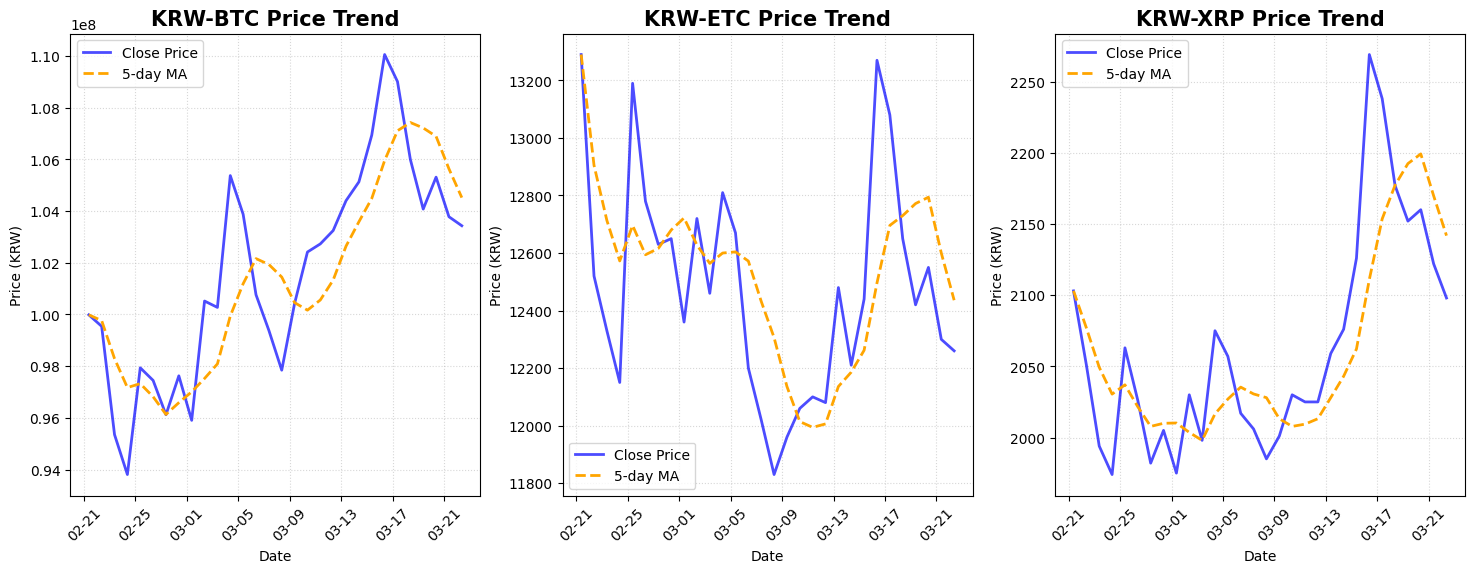

In [70]:
def plot_price_trends(df):
    """가격 트렌드 시각화 함수"""
    print("=== 가격 트렌드 시각화 ===")

    # 날짜 컬럼을 datetime으로 변환
    df['date'] = pd.to_datetime(df['date_str'])

    # 고유 티커 목록. 중복제거
    tickers = df['ticker'].unique()

    # 서브플롯 생성
    # "가로로 1행, 세로로 3열" 가로로 긴 도화지를 3칸으로 나눠라라는 뜻
    # figsize=(18, 6): 도화지 전체 크기. 가로 18인치, 세로 6인치
    # fig: 도화지 전체 / axes: 나눠진 3개의 칸(그림판)들
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes = axes.flatten() # 3개의 칸을 [0번 칸, 1번 칸, 2번 칸]처럼 한 줄로 쭉 펴서 다루기 쉽게 만드는 작업

    # i는 번호(0, 1, 2), ticker는 코인 이름
    # "0번 칸에는 비트코인, 1번 칸에는 이더리움..." 이렇게 순서대로 작업을 반복
    for i, ticker in enumerate(tickers):

        # 전체 데이터에서 지금 차례인 코인의 데이터만 필터링해서 가져온 뒤, 날짜순으로 줄을 세움
        ticker_data = df[df['ticker'] == ticker].sort_values('date')

        ax = axes[i] # 이번 코인은 i번째 칸에 그릴 거라고 그림판을 지정

        ##############################################################
          #### 문제3) 종가와 5일 이동평균선 시각화의 답안을 작성해주세요 ####
        # 1. 종가(Close) 그리기 - 파란색 실선
        ax.plot(ticker_data['date'], ticker_data['close'],
                label='Close Price', color='blue', linewidth=2, alpha=0.7)

        # 2. 5일 이동평균선(MA5) 그리기 - 주황색 점선
        # 구분하기 쉽게 점선(linestyle='--')으로 표현하는 것이 팁입니다!
        ax.plot(ticker_data['date'], ticker_data['ma5'],
                label='5-day MA', color='orange', linestyle='--', linewidth=2)

        # 3. 그래프 꾸미기 (제목, 라벨, 범례)
        ax.set_title(f"{ticker} Price Trend", fontsize=15, fontweight='bold')
        ax.set_xlabel("Date")
        ax.set_ylabel("Price (KRW)")
        ax.legend(loc='best') # 가장 적절한 위치에 범례 배치
        ax.grid(True, linestyle=':', alpha=0.5) # 격자 추가로 가독성 업

        ##############################################################

        # 날짜 포맷 설정
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax.tick_params(axis='x', rotation=45)

    plt.show()



# 시각화 실행
plot_price_trends(db_data)